In [2]:
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [3]:
from pathlib import Path

REPORTS_DIR = Path("../reports/figures")

REPORTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print(f"Saving plots to: {REPORTS_DIR.resolve()}")

Saving plots to: D:\Projects\patient-readmission\reports\figures


In [4]:
DATA_PATH = "../data/diabetic_data.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [5]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Rows: 101,766
Columns: 50


In [6]:
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [8]:
df.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [9]:
df.describe(include="object")

,race,gender,age,weight,payer_code,medical_specialty,diag_1,diag_2,diag_3,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
count,101766,101766,101766,101766,101766,101766,101766,101766,101766,5346,17018,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766
unique,6,3,10,10,18,73,717,749,790,3,3,4,4,4,4,4,2,4,4,2,4,4,4,4,2,3,1,1,4,4,2,2,2,2,2,2,3
top,Caucasian,Female,[70-80),?,?,?,428,276,250,Norm,>8,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
freq,76099,54708,26068,98569,40256,49949,6862,6752,11555,2597,8216,81778,100227,101063,101680,96575,101765,89080,91116,101743,94438,95401,101458,101728,101763,101727,101766,101766,47383,101060,101753,101765,101764,101765,54755,78363,54864


In [10]:
data_dictionary = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.values
})

data_dictionary

,column,dtype
0,encounter_id,int64
1,patient_nbr,int64
2,race,object
3,gender,object
4,age,object
5,weight,object
6,admission_type_id,int64
7,discharge_disposition_id,int64
8,admission_source_id,int64
9,time_in_hospital,int64


In [11]:
data_dictionary.to_csv(
    "../reports/data_dictionary.csv",
    index=False
)

print("Data dictionary saved.")

Data dictionary saved.


In [12]:
missing_df = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": (
        df.isna().sum() / len(df) * 100
    ).round(2)
})

missing_df = (
    missing_df
    .sort_values(
        by="missing_pct",
        ascending=False
    )
)

missing_df.head(20)

,missing_count,missing_pct
max_glu_serum,96420,94.75
A1Cresult,84748,83.28
race,0,0.00
gender,0,0.00
age,0,0.00
weight,0,0.00
admission_type_id,0,0.00
discharge_disposition_id,0,0.00
admission_source_id,0,0.00
time_in_hospital,0,0.00


In [13]:
question_mark_counts = {}

for col in df.columns:
    count = (df[col] == "?").sum()
    if count > 0:
        question_mark_counts[col] = count

question_mark_df = pd.DataFrame(
    question_mark_counts.items(),
    columns=["column", "question_mark_count"]
)

question_mark_df.sort_values(
    by="question_mark_count",
    ascending=False
)

,column,question_mark_count
1,weight,98569
3,medical_specialty,49949
2,payer_code,40256
0,race,2273
6,diag_3,1423
5,diag_2,358
4,diag_1,21


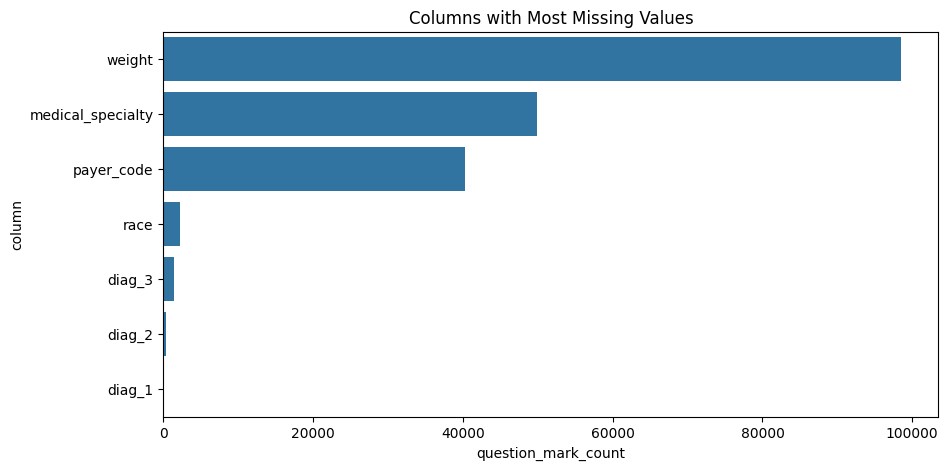

In [14]:
top_missing = (
    question_mark_df
    .sort_values(
        by="question_mark_count",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=top_missing,
    x="question_mark_count",
    y="column"
)

plt.title("Columns with Most Missing Values")
plt.show()

In [15]:
duplicate_count = df.duplicated().sum()

print(
    f"Duplicate rows: {duplicate_count:,}"
)

Duplicate rows: 0


In [16]:
print(
    "Unique patients:",
    df["patient_nbr"].nunique()
)

print(
    "Unique encounters:",
    df["encounter_id"].nunique()
)

Unique patients: 71518
Unique encounters: 101766


In [17]:
df["readmitted"].value_counts()

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

In [18]:
target_preview = (
    df["readmitted"]
    .value_counts(normalize=True)
    * 100
)

target_preview.round(2)

readmitted
NO     53.91
>30    34.93
<30    11.16
Name: proportion, dtype: float64

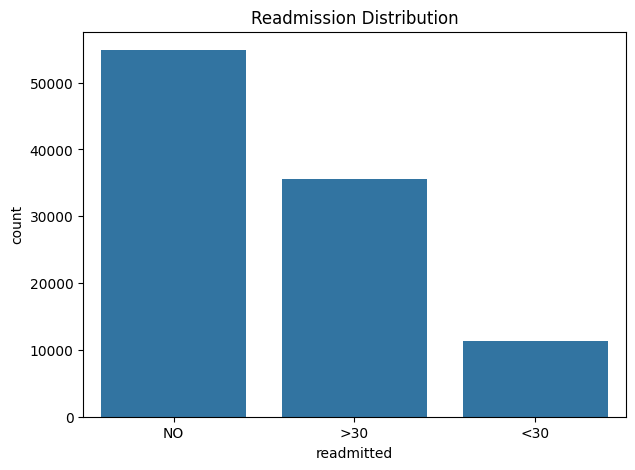

In [19]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="readmitted"
)

plt.title("Readmission Distribution")
plt.show()

In [20]:
readmit_30_pct = (
    (df["readmitted"] == "<30")
    .mean()
    * 100
)

print(
    f"Readmitted <30 days: "
    f"{readmit_30_pct:.2f}%"
)

Readmitted <30 days: 11.16%


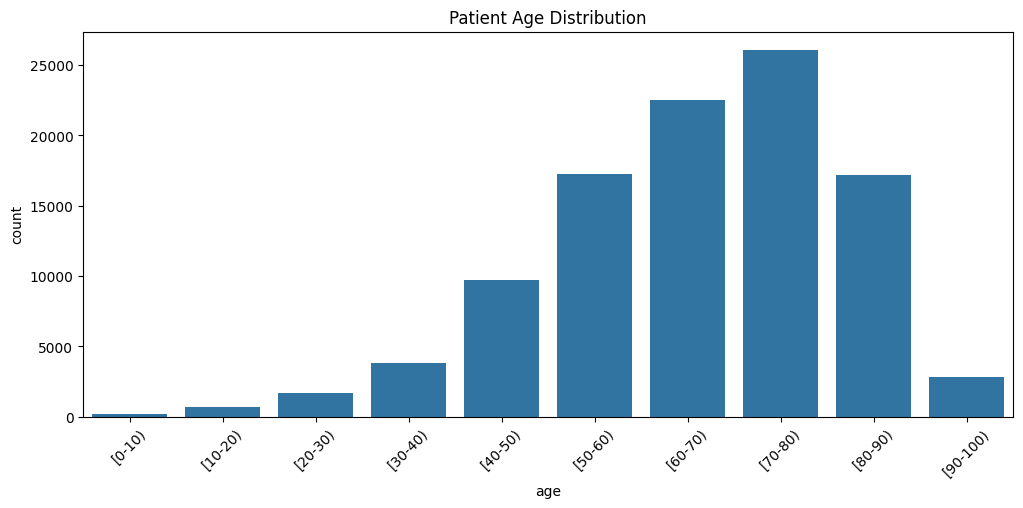

In [21]:
plt.figure(figsize=(12, 5))

sns.countplot(
    data=df,
    x="age"
)

plt.xticks(rotation=45)

plt.title("Patient Age Distribution")

plt.show()

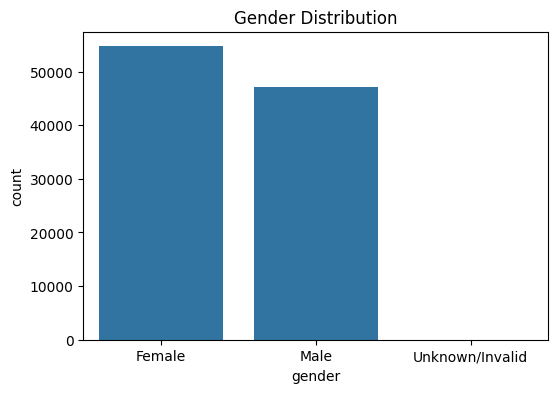

In [22]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="gender"
)

plt.title("Gender Distribution")

plt.show()

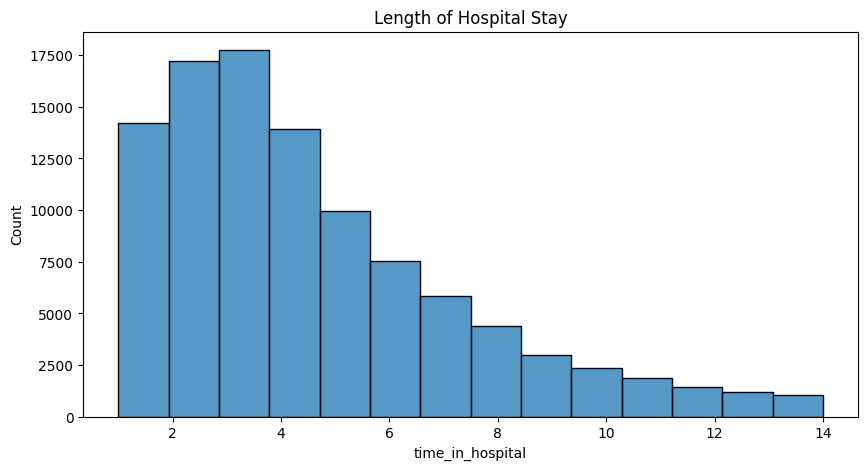

In [23]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["time_in_hospital"],
    bins=14
)

plt.title("Length of Hospital Stay")

plt.show()

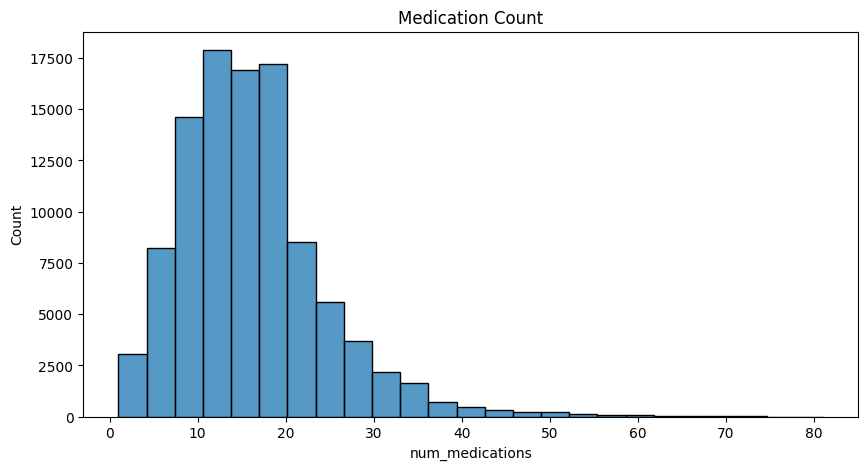

In [24]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["num_medications"],
    bins=25
)

plt.title("Medication Count")

plt.show()

In [25]:
numeric_df = df.select_dtypes(
    include=["int64", "float64"]
)

corr = numeric_df.corr()

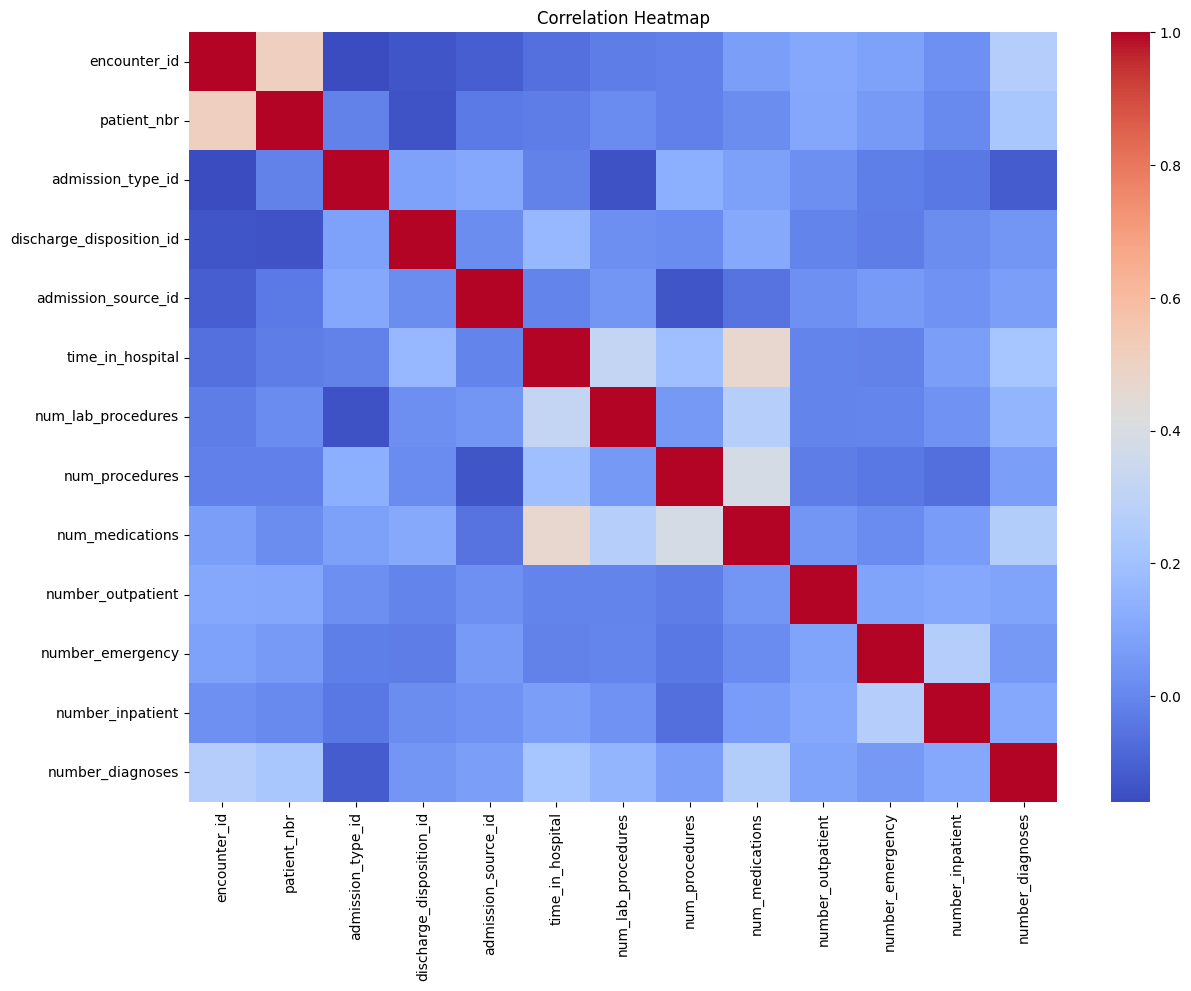

In [26]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.title(
    "Correlation Heatmap"
)

plt.show()

In [27]:
potential_leakage_cols = [
    "encounter_id",
    "patient_nbr"
]

df[potential_leakage_cols].head()

,encounter_id,patient_nbr
0,2278392,8222157
1,149190,55629189
2,64410,86047875
3,500364,82442376
4,16680,42519267


## Key Findings

### Dataset

- 101,766 hospital encounters
- 50 features

### Target

- Readmitted within 30 days is minority class
- Approximately 11% positive cases

### Missing Values

Major issues:

- weight
- payer_code
- medical_specialty

Contain large numbers of '?' values.

### Patient Demographics

- Majority are older adults
- Multiple encounters per patient

### Clinical Indicators

Potentially useful predictors:

- time_in_hospital
- num_medications
- num_lab_procedures
- number_diagnoses
- number_inpatient
- number_emergency
- number_outpatient

### Potential Leakage

- encounter_id
- patient_nbr

Likely unsuitable for modeling.

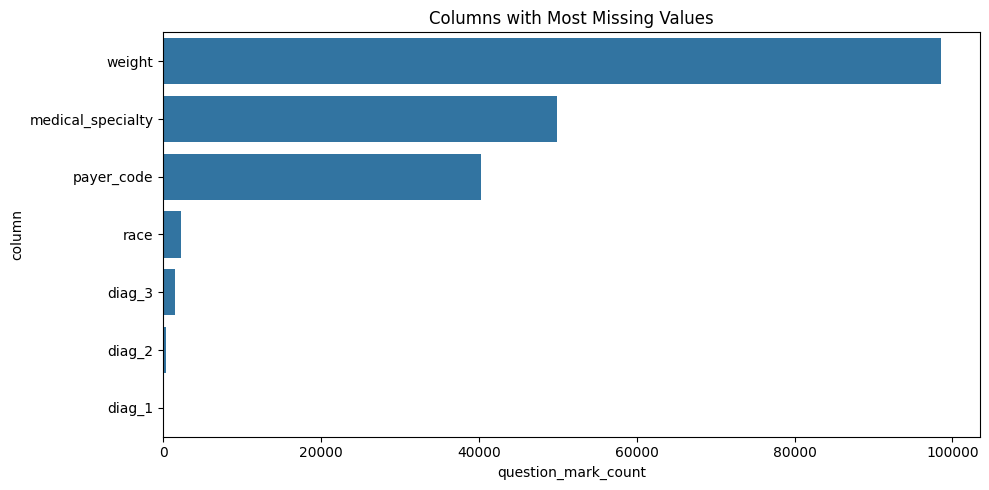

In [28]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=top_missing,
    x="question_mark_count",
    y="column"
)

plt.title("Columns with Most Missing Values")

plt.tight_layout()

plt.savefig(
    REPORTS_DIR / "missing_values.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

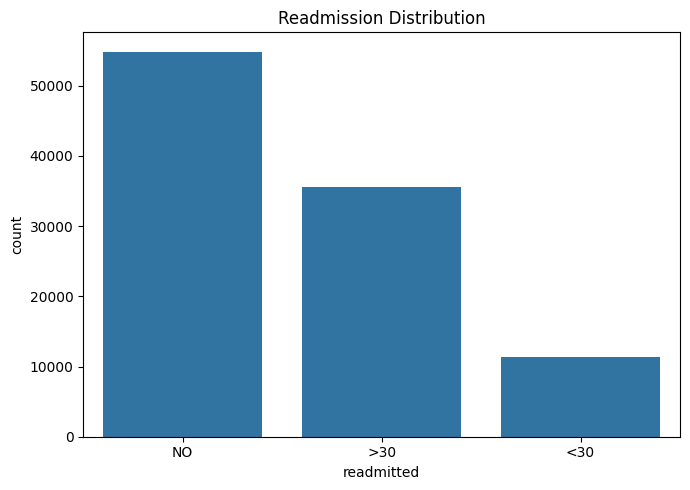

In [29]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="readmitted"
)

plt.title("Readmission Distribution")

plt.tight_layout()

plt.savefig(
    REPORTS_DIR / "target_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

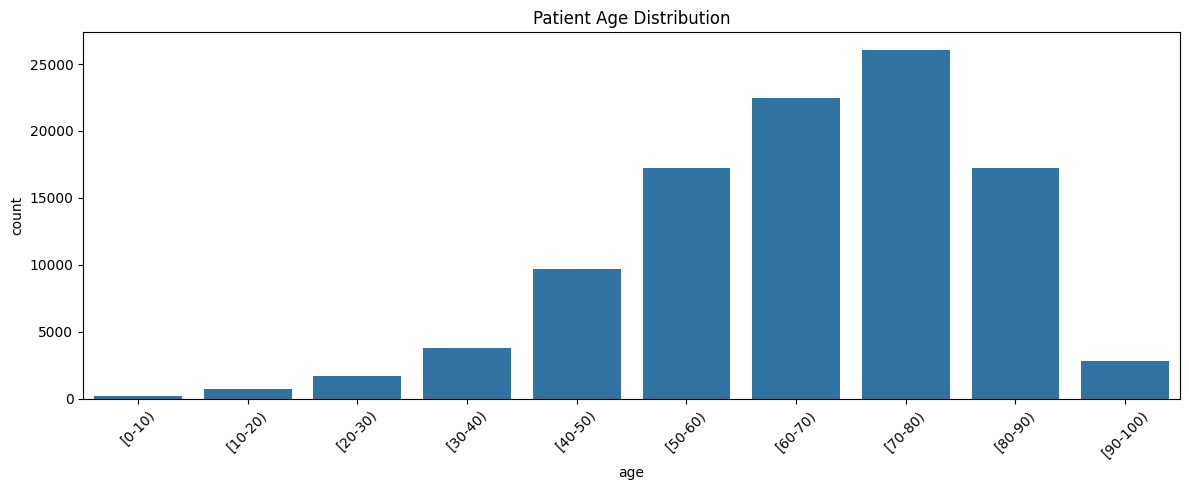

In [30]:
plt.figure(figsize=(12, 5))

sns.countplot(
    data=df,
    x="age"
)

plt.xticks(rotation=45)

plt.title("Patient Age Distribution")

plt.tight_layout()

plt.savefig(
    REPORTS_DIR / "age_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

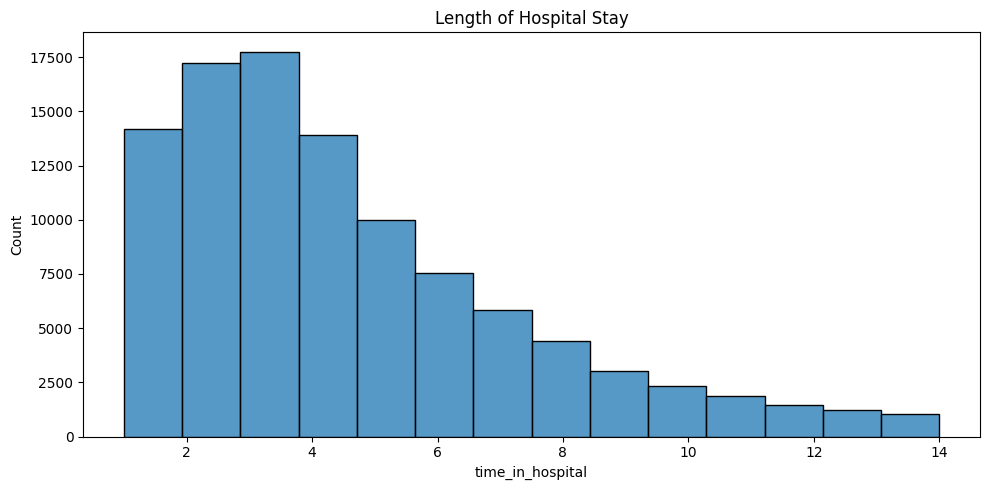

In [31]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["time_in_hospital"],
    bins=14
)

plt.title("Length of Hospital Stay")

plt.tight_layout()

plt.savefig(
    REPORTS_DIR / "hospital_stay_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

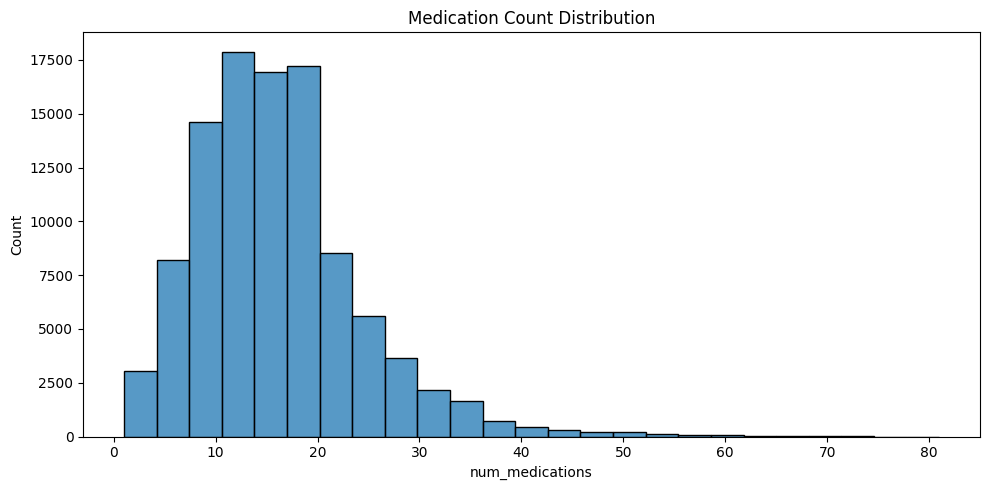

In [32]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["num_medications"],
    bins=25
)

plt.title("Medication Count Distribution")

plt.tight_layout()

plt.savefig(
    REPORTS_DIR / "medication_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

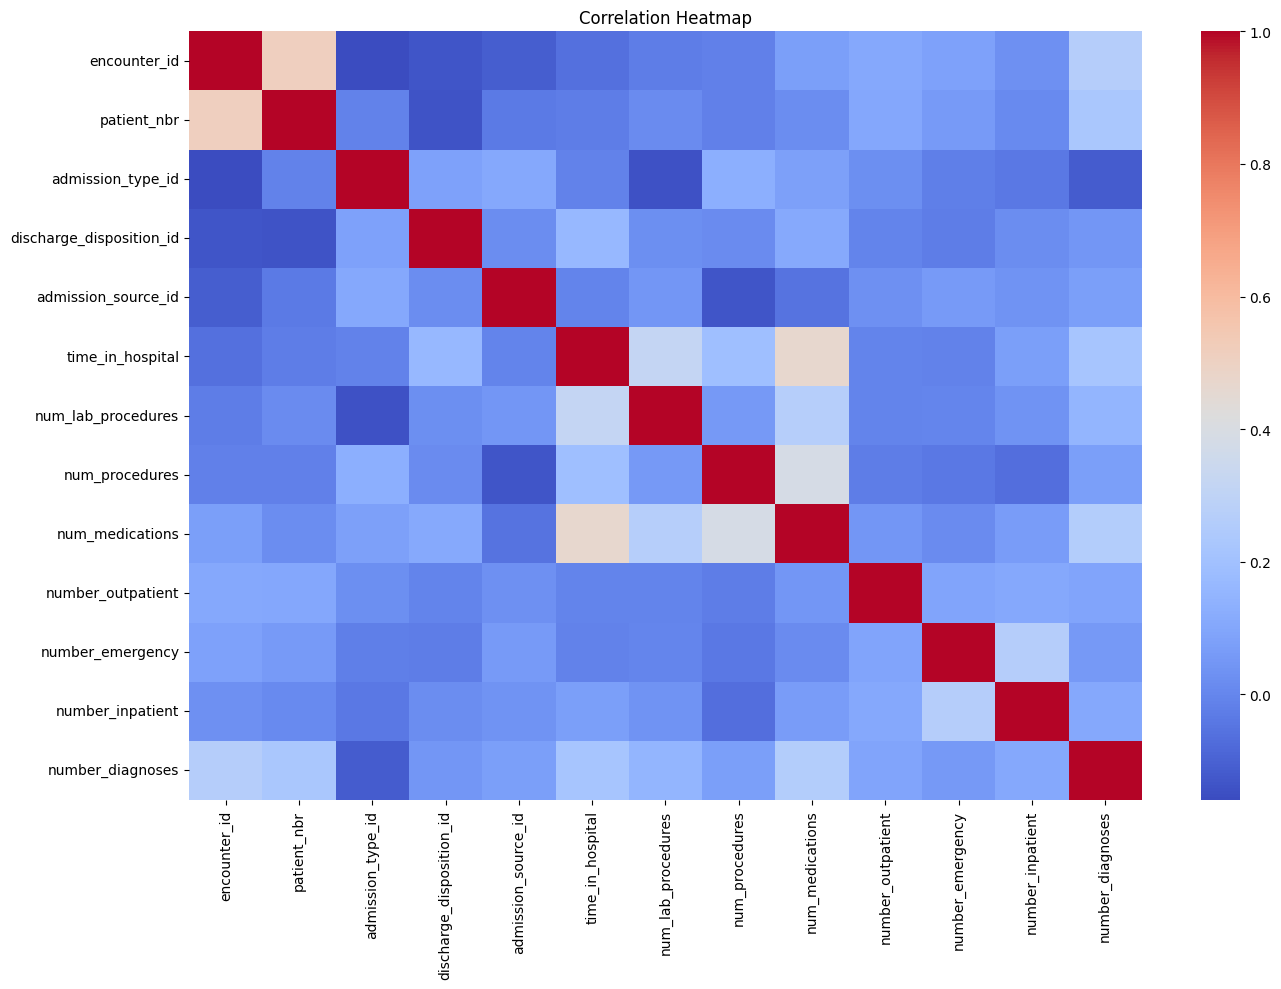

In [33]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig(
    REPORTS_DIR / "correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [34]:
import os

for file in os.listdir("../reports/figures"):
    print(file)

age_distribution.png
correlation_heatmap.png
hospital_stay_distribution.png
medication_distribution.png
missing_values.png
target_distribution.png
